# LightGBM fitting and testing

In [1]:
import pandas as pd

#df = pd.read_parquet('Mistral_512tok.parquet')
df = pd.read_parquet('Mistral_512tok_50prompts.parquet')

## Cross-prompt generalization

### First test: single target

In [2]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd
from modeling import split_by_prompt, head_mean_baseline, train_lgbm, evaluate, run_cross_prompt_experiment, plot_top_features, plot_r2_vs_lift_panels, plot_shap_run, run_cross_prompt_all_targets, _run_one, aggregate_per_head, split_by_head, global_mean_baseline, nearest_neighbor_baseline, train_lgbm_head, evaluate_head, plot_shap_crosshead, run_cross_head_experiment, add_normalized_features, split_by_length_stratified, run_length_generalization

PTYPE_WIKI = "wikitext_wikitext-103-raw-v1_train"
PTYPE_RAND = "random_vocab"

# ── Classificazione feature ───────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq", "gini_right_Wq",
    "gini_left_Wk", "gini_right_Wk",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    #"rmsnorm_gamma_norm",
    "compute_WqRWk_alignment_delta_0",
]

INPUT_DEP_FEATURES = [
    #"effective_rank_H", "r95_H",
    #"effective_rank_Q", "r95_Q",
    #"effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    #"svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

#TARGET = "attention_gini"
TARGET = "sink_mass_token_0"

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# Functions moved to modeling.py

# ── Run ───────────────────────────────────────────────────────────────────────
results_cp = run_cross_prompt_experiment(df)

/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 81,920 obs (80 prompts)
Val:   10,240 obs (10 prompts)
Test:  10,240 obs (10 prompts)

── Variante: offline (17 features) ──
  R²:               0.7216
  MAE (model):      0.07984
  MAE (baseline):   0.07975
  Improvement:      -0.00009

── Variante: oracle (19 features) ──
  R²:               0.9159
  MAE (model):      0.04124
  MAE (baseline):   0.07975
  Improvement:      0.03851


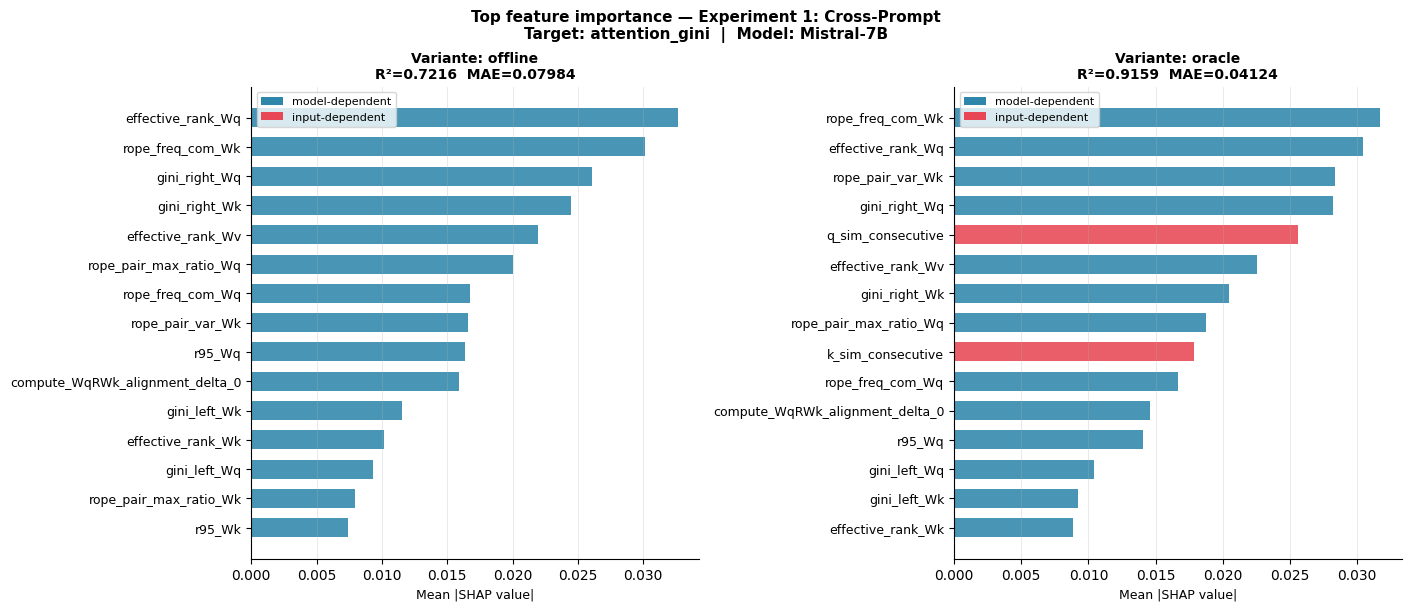

In [45]:
# function moved to modeling.py

plot_top_features(results_cp, top_n=15)

### second test: all targets

In [3]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd


# ── Feature sets ──────────────────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq",  "gini_right_Wq",
    "gini_left_Wk",  "gini_right_Wk",
    "rope_pair_var_Wq",       "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq",       "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
]

INPUT_DEP_FEATURES = [
    "q_sim_consecutive",
    "k_sim_consecutive",
]

# ── Tutti i target da valutare ────────────────────────────────────────────────
ALL_TARGETS = [
    # Attention map structure
    "attention_gini",
    # Diagonal
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    # Sink
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    # Structural
    "look_back",
    # Rank
    "effective_rank_A", "r95_A",
]

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# Functions moved to modeling.py

df_summary = run_cross_prompt_all_targets(df)

pivot = df_summary[["R2", "MAE", "lift"]].unstack("variant")
pivot.columns = [f"{col[0]}_{col[1]}" for col in pivot.columns]
print("\n" + "═"*80)
print("SUMMARY — Cross-Prompt  |  all targets × all variants")
print("═"*80)
print(pivot.to_string(float_format=lambda x: f"{x:.4f}"))

Train: 81,920 | Val: 10,240 | Test: 10,240

[  1/32] attention_gini                      offline R²=0.6489  MAE=0.02488  lift=-2.4%
[  2/32] attention_gini                      oracle R²=0.9183  MAE=0.01099  lift=+54.8%
[  3/32] diagonal_mass_1                     offline R²=0.8253  MAE=0.01120  lift=-1.3%
[  4/32] diagonal_mass_1                     oracle R²=0.9662  MAE=0.00573  lift=+48.2%
[  5/32] diagonal_mass_5                     offline R²=0.8420  MAE=0.02320  lift=-1.5%
[  6/32] diagonal_mass_5                     oracle R²=0.9581  MAE=0.01254  lift=+45.1%
[  7/32] diagonal_mass_1_shifted_1           offline R²=0.8344  MAE=0.00994  lift=-1.9%
[  8/32] diagonal_mass_1_shifted_1           oracle R²=0.9660  MAE=0.00533  lift=+45.4%
[  9/32] diagonal_mass_1_shifted_2           offline R²=0.7290  MAE=0.00570  lift=-0.8%
[ 10/32] diagonal_mass_1_shifted_2           oracle R²=0.9373  MAE=0.00307  lift=+45.7%
[ 11/32] diagonal_mass_1_shifted_3           offline R²=0.7089  MAE=0.00423 

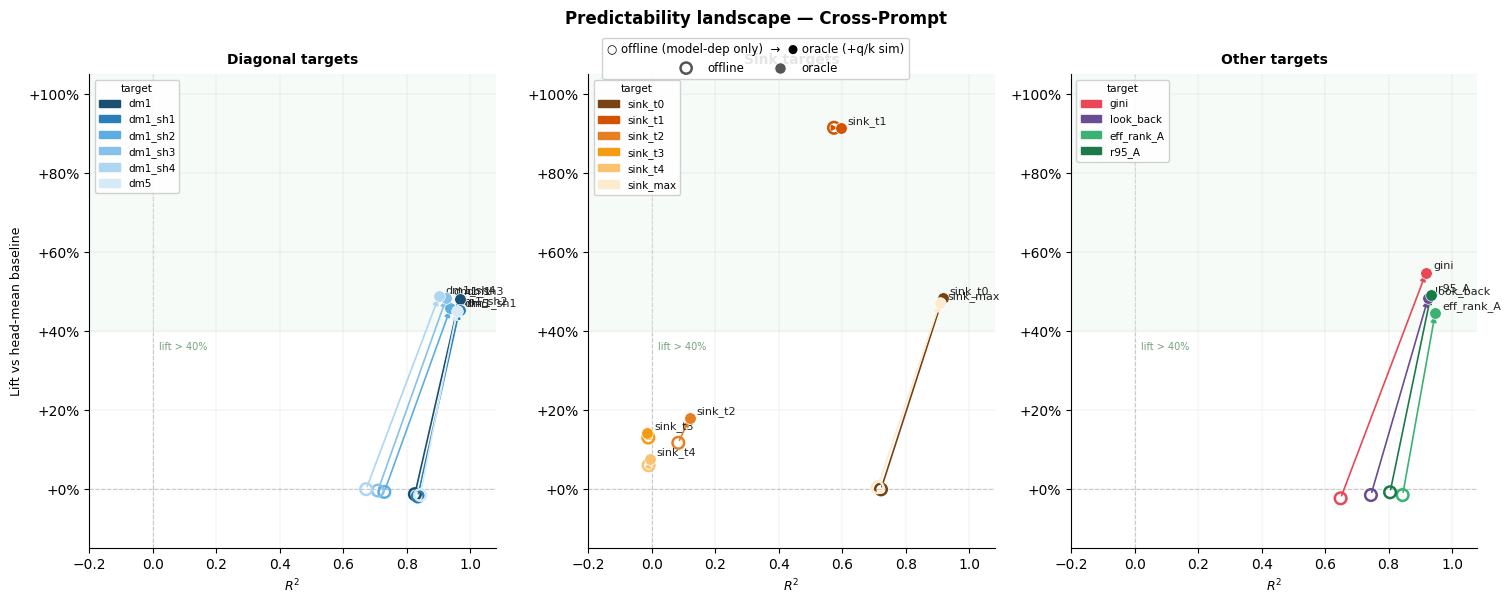

In [4]:
# improvement bewteen model-only features and model+input features
plot_r2_vs_lift_panels(pivot)


════════════════════════════════════════════════════════════
EXPERIMENT 2 — Cross-Head Generalization
════════════════════════════════════════════════════════════
Prompt source: wikitext_wikitext-103-raw-v1_train

── Variante: offline (17 features) ──
  Teste totali: 1024
  Train: 820 heads | Val: 102 heads | Test: 102 heads
  R²:              0.5891
  MAE (model):     0.08762
  MAE (global μ):  0.14505  lift=+39.6%
  MAE (1-NN):      0.12247  lift=+28.5%

── Variante: oracle (19 features) ──
  Teste totali: 1024
  Train: 820 heads | Val: 102 heads | Test: 102 heads
  R²:              0.5766
  MAE (model):     0.08824
  MAE (global μ):  0.14505  lift=+39.2%
  MAE (1-NN):      0.12247  lift=+28.0%


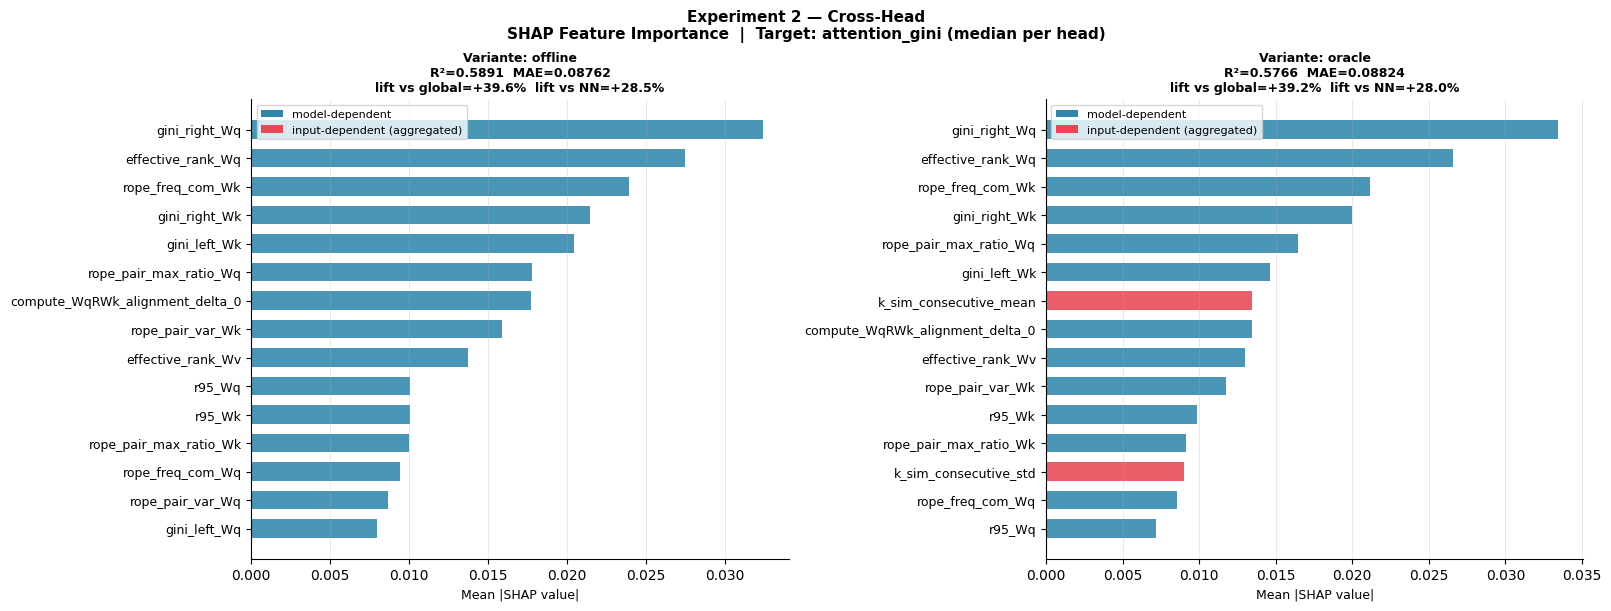

In [5]:
# Functions moved to modeling.py

# ── Run ───────────────────────────────────────────────────────────────────────
results_ch = run_cross_head_experiment(df, prompt_source=PTYPE_WIKI)

In [36]:
df_multi = pd.read_parquet("Mistral_multi_tok.parquet")

In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd


# ── Feature sets ──────────────────────────────────────────────────────────────
MODEL_DEP_FEATURES = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "gini_left_Wq",  "gini_right_Wq",
    "gini_left_Wk",  "gini_right_Wk",
    "rope_pair_var_Wq",       "rope_pair_var_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq",       "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
    # prompt_len come feature esplicita — utile in train multi-lunghezza
    "prompt_len",
]

INPUT_DEP_FEATURES_RAW = [
    "q_sim_consecutive",
    "k_sim_consecutive",
]
'''
# Feature input-dependent normalizzate per prompt_len
INPUT_DEP_FEATURES_NORM = [
    "q_sim_consecutive_norm",
    "k_sim_consecutive_norm",
]'''

INPUT_DEP_FEATURES = INPUT_DEP_FEATURES_RAW #+ INPUT_DEP_FEATURES_NORM


# ── Tutti i target da valutare ────────────────────────────────────────────────
ALL_TARGETS = [
    "attention_gini",
    "diagonal_mass_1", "diagonal_mass_5",
    #"diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    #"diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    #"sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    #"look_back",
    #"effective_rank_A", "r95_A",
]

FEATURE_SETS = {
    "offline": MODEL_DEP_FEATURES,
    "oracle":  MODEL_DEP_FEATURES + INPUT_DEP_FEATURES,
}

# Functions moved to modeling.py

df_multi = pd.read_parquet("Mistral_multi_tok.parquet")
df_summary = run_length_generalization(df_multi)

pivot = df_summary[["R2", "MAE", "lift"]].unstack("variant")
pivot.columns = [f"{col[0]}_{col[1]}" for col in pivot.columns]
print("\n" + "═"*80)
print("SUMMARY — Length Generalization  |  train={64,128,256} → test={512}")
print("═"*80)
print(pivot.to_string(float_format=lambda x: f"{x:.4f}"))

Train: 26,624 rows | prompt_len distribution: {64: 26624}
Val:   4,096 rows  | prompt_len distribution: {64: 4096}
Test:  92,160 rows | prompt_len distribution: {128: 30720, 256: 30720, 512: 30720}

Train prompt_source x prompt_len:
prompt_source                         prompt_len
fineweb-edu_sample-10BT_train_stream  64            13
wikitext_wikitext-103-raw-v1_train    64            13

[  1/12] attention_gini                      offline R²=0.3894  MAE=0.03490  lift=+4.6%
[  2/12] attention_gini                      oracle R²=0.4196  MAE=0.03385  lift=+7.5%
[  3/12] diagonal_mass_1                     offline R²=0.8898  MAE=0.01640  lift=+3.8%
[  4/12] diagonal_mass_1                     oracle R²=0.9022  MAE=0.01517  lift=+10.9%
[  5/12] diagonal_mass_5                     offline R²=0.7859  MAE=0.04181  lift=+3.3%
[  6/12] diagonal_mass_5                     oracle R²=0.8065  MAE=0.03955  lift=+8.5%
[  7/12] sink_mass_token_0                   offline R²=0.5576  MAE=0.09924  lift